![](https://media.giphy.com/media/3o6MbrACMlFCny8zmw/giphy.gif)

Remember the rules of ~Fight~ Code Club:
1. ALWAYS DOCUMENT
2. Cite resources that you use (paste links)
3. Include the names people who you worked with
4. Be neat and organized

# Question 1

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a line graph of total population over time for the states: NY, PA, CT, NJ (10 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Specify colors to be used in your code. (5 pts)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

cities = pd.read_csv('us-cities-top-1k-multi-year.csv')
jobs = pd.read_csv('job-automation-probability.csv')


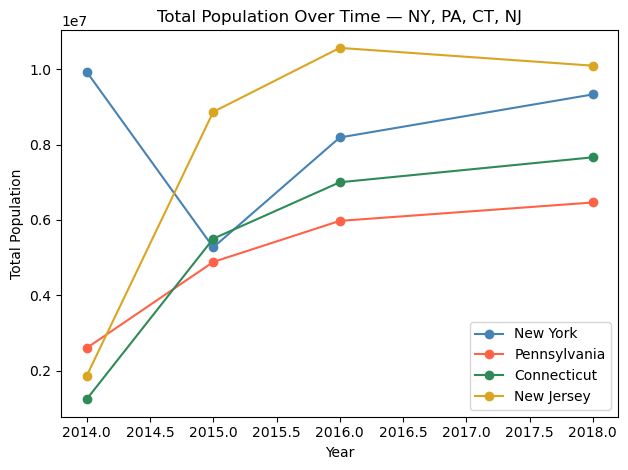

In [4]:
# filter to just the four states we need
ne_states = ['New York', 'Pennsylvania', 'Connecticut', 'New Jersey']
ne = cities[cities['State'].isin(ne_states)]

# total population per state per year
ne_pop = ne.groupby(['State', 'year'])['Population'].sum().reset_index()

# colors for each state
state_colors = {
'New York': 'steelblue',
'Pennsylvania': 'tomato',
'Connecticut': 'seagreen',
'New Jersey': 'goldenrod'
}

fig1, ax1 = plt.subplots()

for state in ne_states:
    subset = ne_pop[ne_pop['State'] == state]
    ax1.plot(subset['year'], subset['Population'], label=state, color=state_colors[state], marker='o')

ax1.set_title('Total Population Over Time — NY, PA, CT, NJ')
ax1.set_xlabel('Year')
ax1.set_ylabel('Total Population')
ax1.legend()
plt.tight_layout()
plt.show()

# Question 2

Using the dataset "us-cities-top-1k-multi-year.csv":
1. Create a Bar Graph of the total population for 5 cities in the state of New York comparing 2014 years and 2018 years (15 pts)
2. Be sure to include a title of the graph, labels on your axis, and a legend. (5 pts)
3. Combine the graph in question 1 and question 2 in one figure.

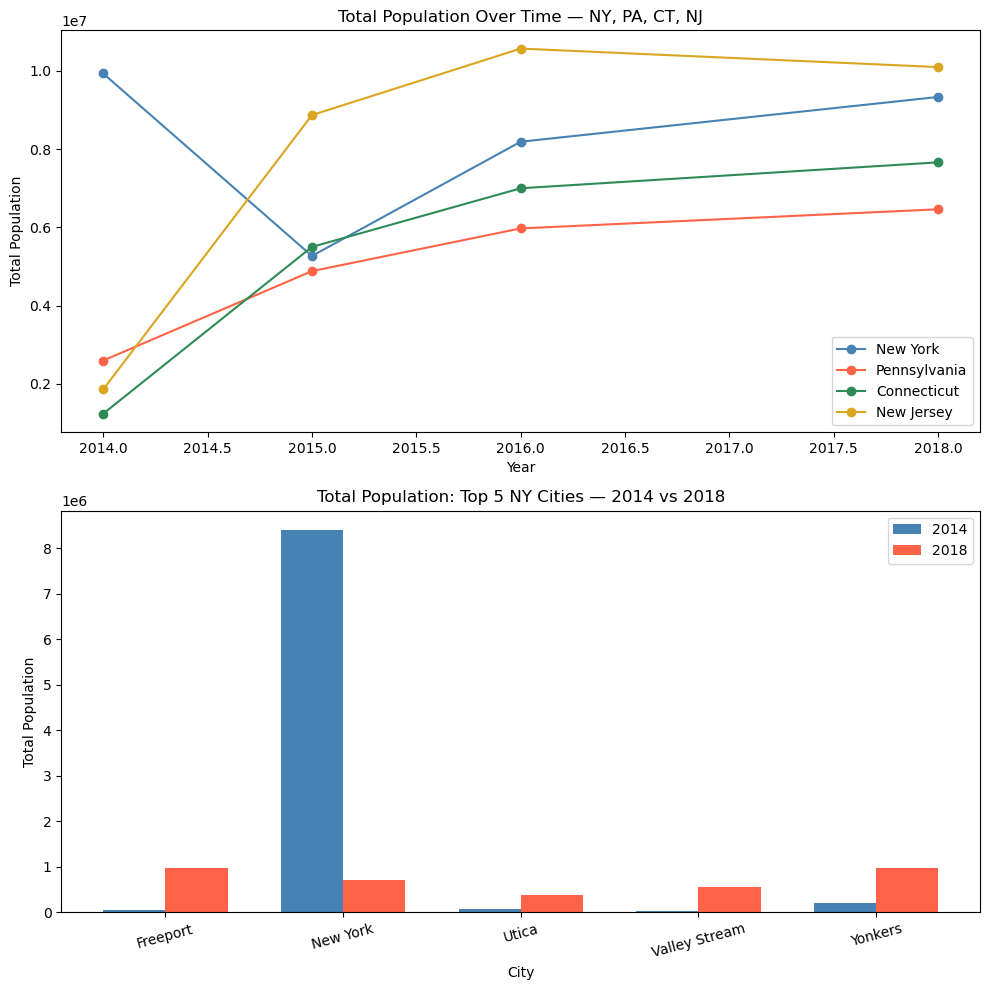

In [6]:
# grab the top 5 NY cities by average population
ny = cities[cities['State'] == 'New York']
top5 = ny.groupby('City')['Population'].mean().nlargest(5).index.tolist()

# filter to those cities and only 2014 and 2018
ny_bar = ny[(ny['City'].isin(top5)) & (ny['year'].isin([2014, 2018]))]
ny_pivot = ny_bar.pivot_table(index='City', columns='year', values='Population')

# combined figure — Q1 on top, Q2 on bottom
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(10, 10))

# Q1 line graph
for state in ne_states:
    subset = ne_pop[ne_pop['State'] == state]
    ax_top.plot(subset['year'], subset['Population'], label=state, color=state_colors[state], marker='o')

ax_top.set_title('Total Population Over Time — NY, PA, CT, NJ')
ax_top.set_xlabel('Year')
ax_top.set_ylabel('Total Population')
ax_top.legend()

# Q2 bar graph
x = np.arange(len(ny_pivot.index))
width = 0.35

ax_bot.bar(x - width/2, ny_pivot[2014], width, label='2014', color='steelblue')
ax_bot.bar(x + width/2, ny_pivot[2018], width, label='2018', color='tomato')

ax_bot.set_title('Total Population: Top 5 NY Cities — 2014 vs 2018')
ax_bot.set_xlabel('City')
ax_bot.set_ylabel('Total Population')
ax_bot.set_xticks(x)
ax_bot.set_xticklabels(ny_pivot.index, rotation=15)
ax_bot.legend()

plt.tight_layout()
plt.show()

## Question 3

import the data "job-automation-probability.csv"
1. A Histogram of the variable 'probability'
2. A scatter plot of 'Average annual wage' and 'numbEmployed'
3. Put both of these graphs in one figure
4. Using item 3, change the ticks of Number Employed axes so that it is in logarithmic axis (hint: it's an option) 
5. Adding onto item 4, add a title and axis labels
6. Save your figure as a png

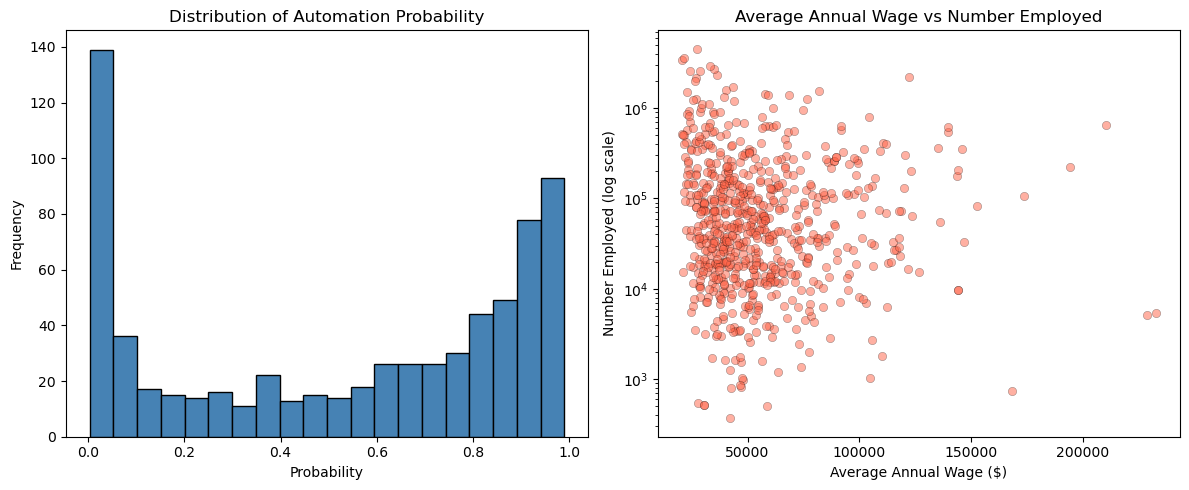

In [7]:
# load the jobs data
jobs = pd.read_csv('job-automation-probability.csv')

# two plots side by side
fig3, (ax_hist, ax_scat) = plt.subplots(1, 2, figsize=(12, 5))

# histogram of probability
ax_hist.hist(jobs['probability'], bins=20, color='steelblue', edgecolor='black')
ax_hist.set_title('Distribution of Automation Probability')
ax_hist.set_xlabel('Probability')
ax_hist.set_ylabel('Frequency')

# scatter plot of wage vs number employed
ax_scat.scatter(jobs['Average annual wage'], jobs['numbEmployed'], alpha=0.5, color='tomato', edgecolors='black', linewidths=0.3)

# set the y axis to log scale
ax_scat.set_yscale('log')

ax_scat.set_title('Average Annual Wage vs Number Employed')
ax_scat.set_xlabel('Average Annual Wage ($)')
ax_scat.set_ylabel('Number Employed (log scale)')

plt.tight_layout()

# save before show or it saves a blank file
plt.savefig('q3_figure.png', dpi=150, bbox_inches='tight')
plt.show()